# 02 — Gaussian message error in non-Gaussian Markov chains (Layer 3)

**Equivalence proposition (message ≡ model at the single-Gaussian level).** For a
linear-transition chain $a_i=\rho a_{i-1}+\varepsilon_i$ with $\mathrm{Var}(\varepsilon)=q$
and Gaussian OU likelihoods, moment-matched single-Gaussian (assumed-density) BP is
*identical* to exact Gaussian BP under the covariance-matched Gaussian AR(1) prior:
the tilted product (Gaussian message × Gaussian likelihood) is exactly Gaussian, and the
transition step maps $N(m,v)$ to a density whose first two moments $(\rho m,\ \rho^2v+q)$
do not depend on the innovation shape. So "Gaussian message error" and "Gaussian model
error" coincide here; separating them requires richer message families (e.g. mixtures).

The *analytic information-form* implementation of this baseline (`gaussian_chain_bp`)
replaces the legacy grid-mediated projection, whose backward messages collapse onto the
grid boundary at weakly informative $t$ (audit finding F1).

Rerun: `python experiments/exp_02_laplace_gaussian_message_error.py` and
`python experiments/exp_03_nongaussian_innovation_sweep.py`.

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import Image, display, Markdown

OUT = Path("..") / "outputs"
pd.set_option("display.float_format", lambda v: f"{v:.4g}")
def show(*names, exp):
    for n in names:
        display(Image(filename=str(OUT / exp / n)))


In [2]:
exp2 = "exp_02_laplace_gaussian_message_error"
summ = pd.read_csv(OUT / exp2 / "laplace_summary.csv")
summ[["t", "rel_score_error_median", "rel_score_error_q90", "p_rel_error_gt_0p1",
      "grid_self_conv_median", "legacy_artifact_max"]]

,t,rel_score_error_median,rel_score_error_q90,p_rel_error_gt_0p1,grid_self_conv_median,legacy_artifact_max
0,0.02,0.3902,0.5947,1,2.544e-05,0.02307
1,0.05,0.2421,0.3164,1,1.105e-05,0.0006053
2,0.08,0.1693,0.2737,1,6.11e-06,0.007886
3,0.12,0.1323,0.2868,0.8667,2.789e-06,0.02334
4,0.18,0.08502,0.1795,0.2667,1.432e-06,0.007167
5,0.27,0.05494,0.1139,0.15,6.685e-07,0.4474
6,0.4,0.03478,0.06375,0.05,4.28e-07,1.437
7,0.6,0.01841,0.03655,0.03333,3.179e-07,0.5396
8,0.9,0.008841,0.01306,0,2.482e-07,5.037
9,1.3,0.00315,0.005904,0,1.693e-07,6.055


Three things to read off this table:
1. the corrected closure error decays **monotonically** with $t$ — the old package's
   large-$t$ anomalies were the legacy artifact (last column: posterior-mean errors up
   to ~6.6 at $t\geq0.9$, in a regime where the true closure error is $<10^{-2}$);
2. the grid self-convergence error stays 4–7 orders of magnitude below the closure
   error, so the reference is trustworthy;
3. at small $t$ the Gaussian baseline fails for *every* trial
   ($P(\mathrm{err}>0.1)=1$), as predicted by the $\alpha_t/\Delta_t$ amplification.

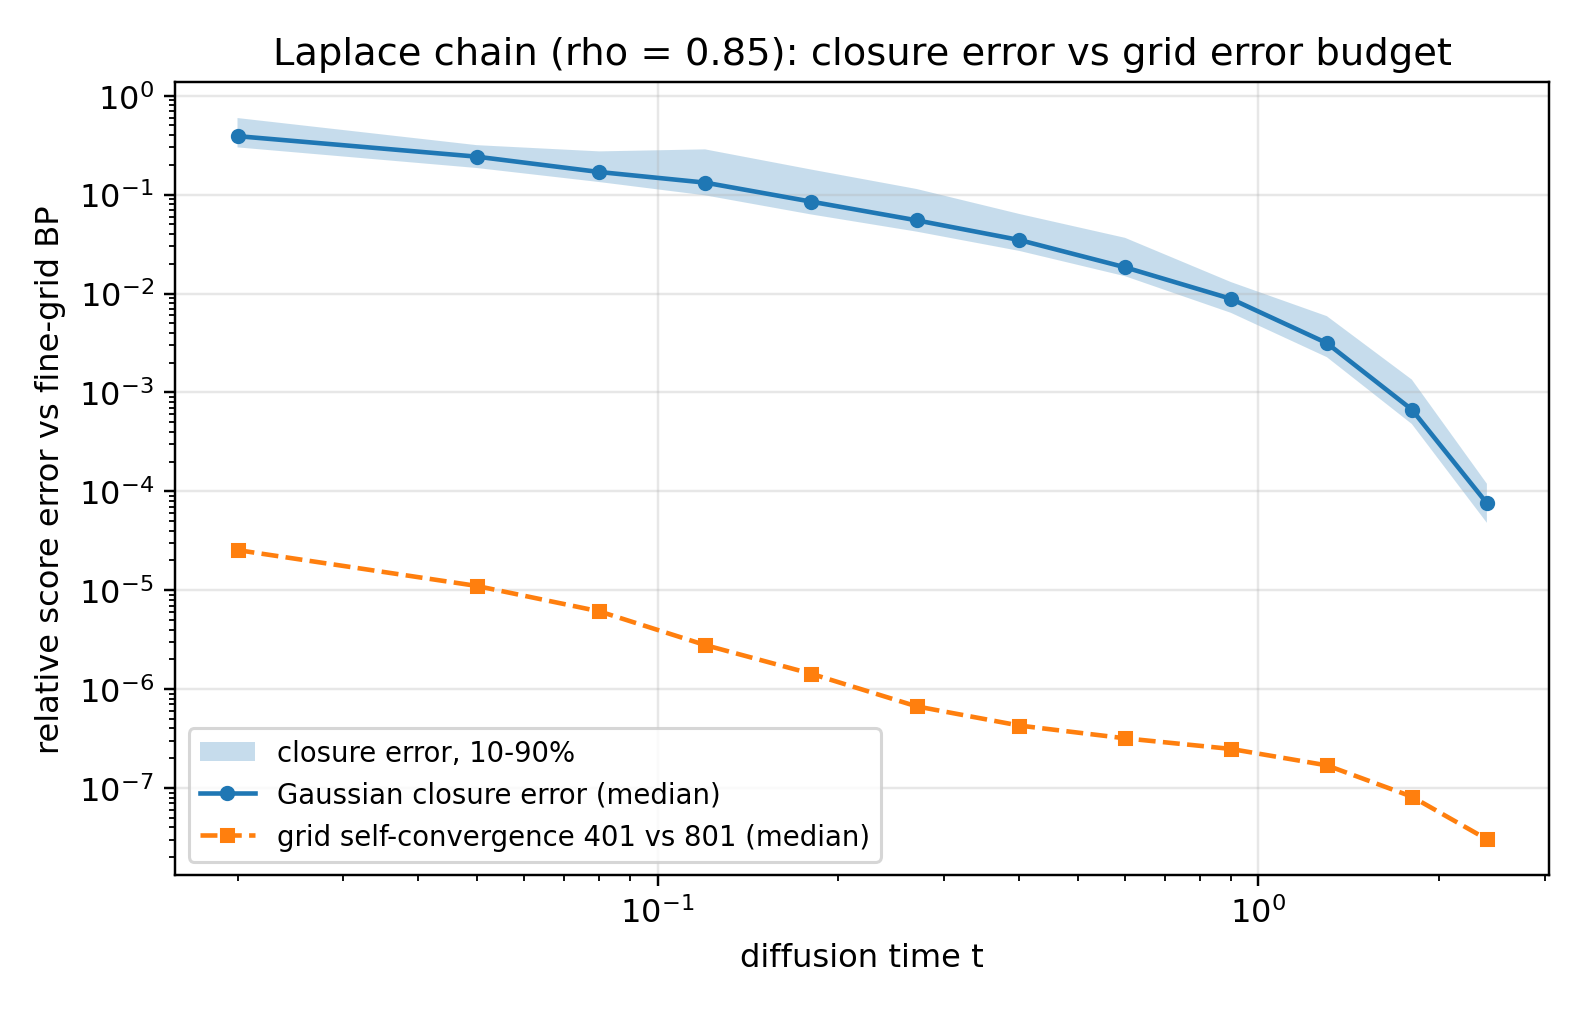

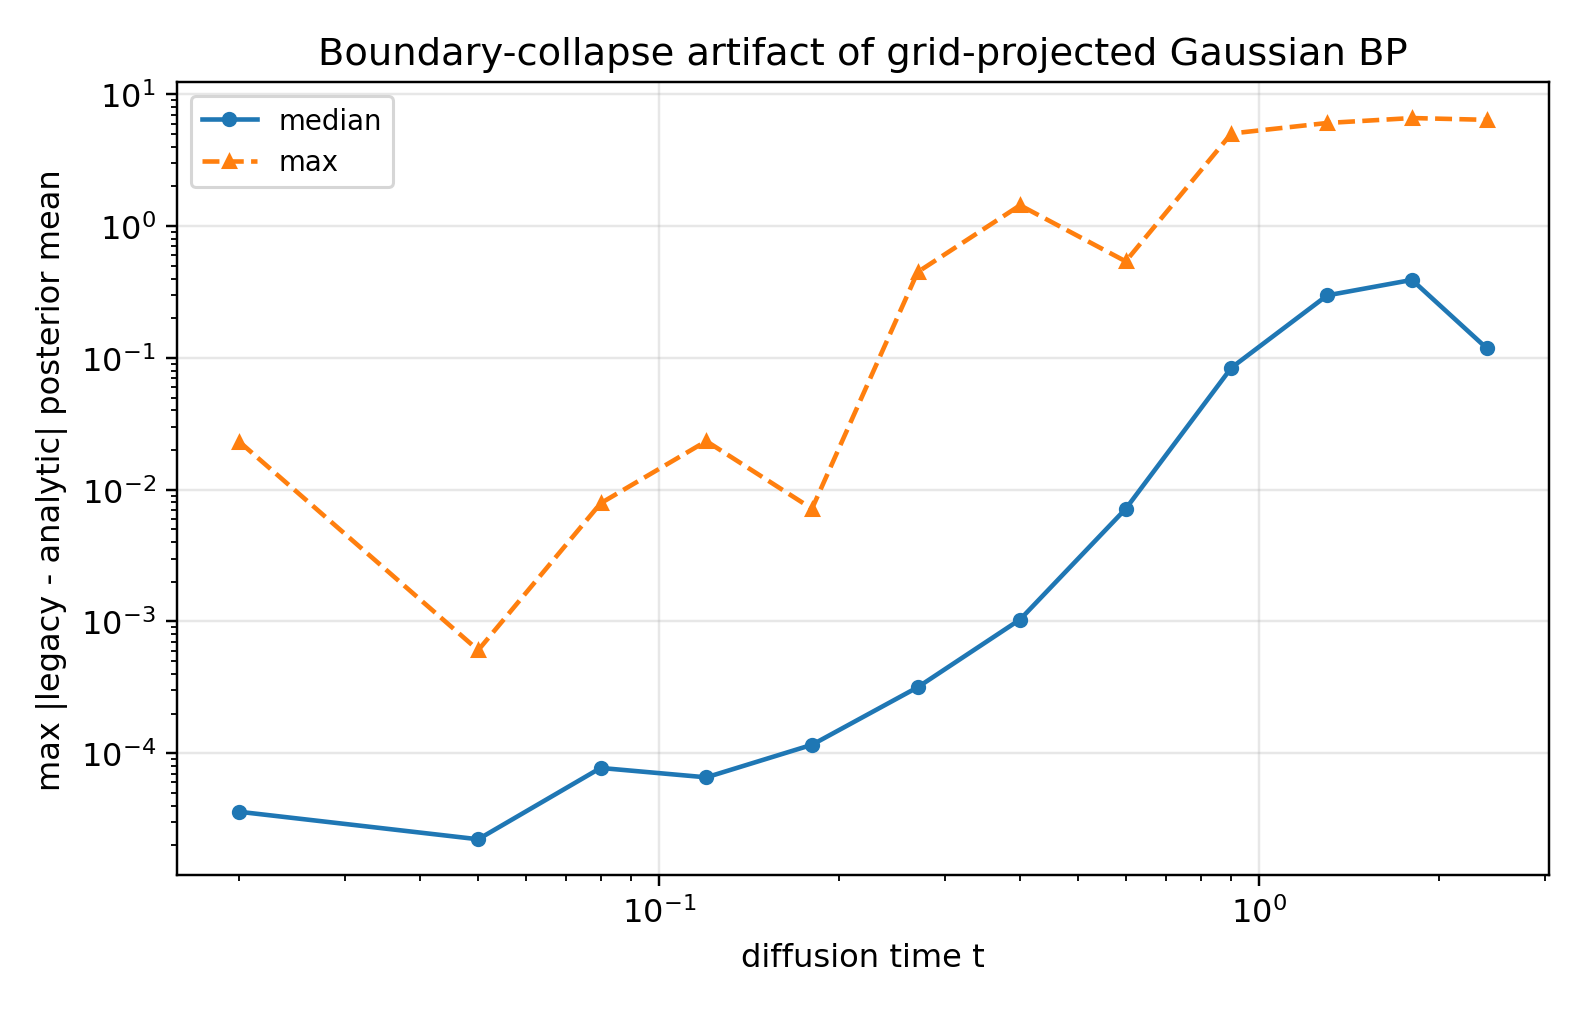

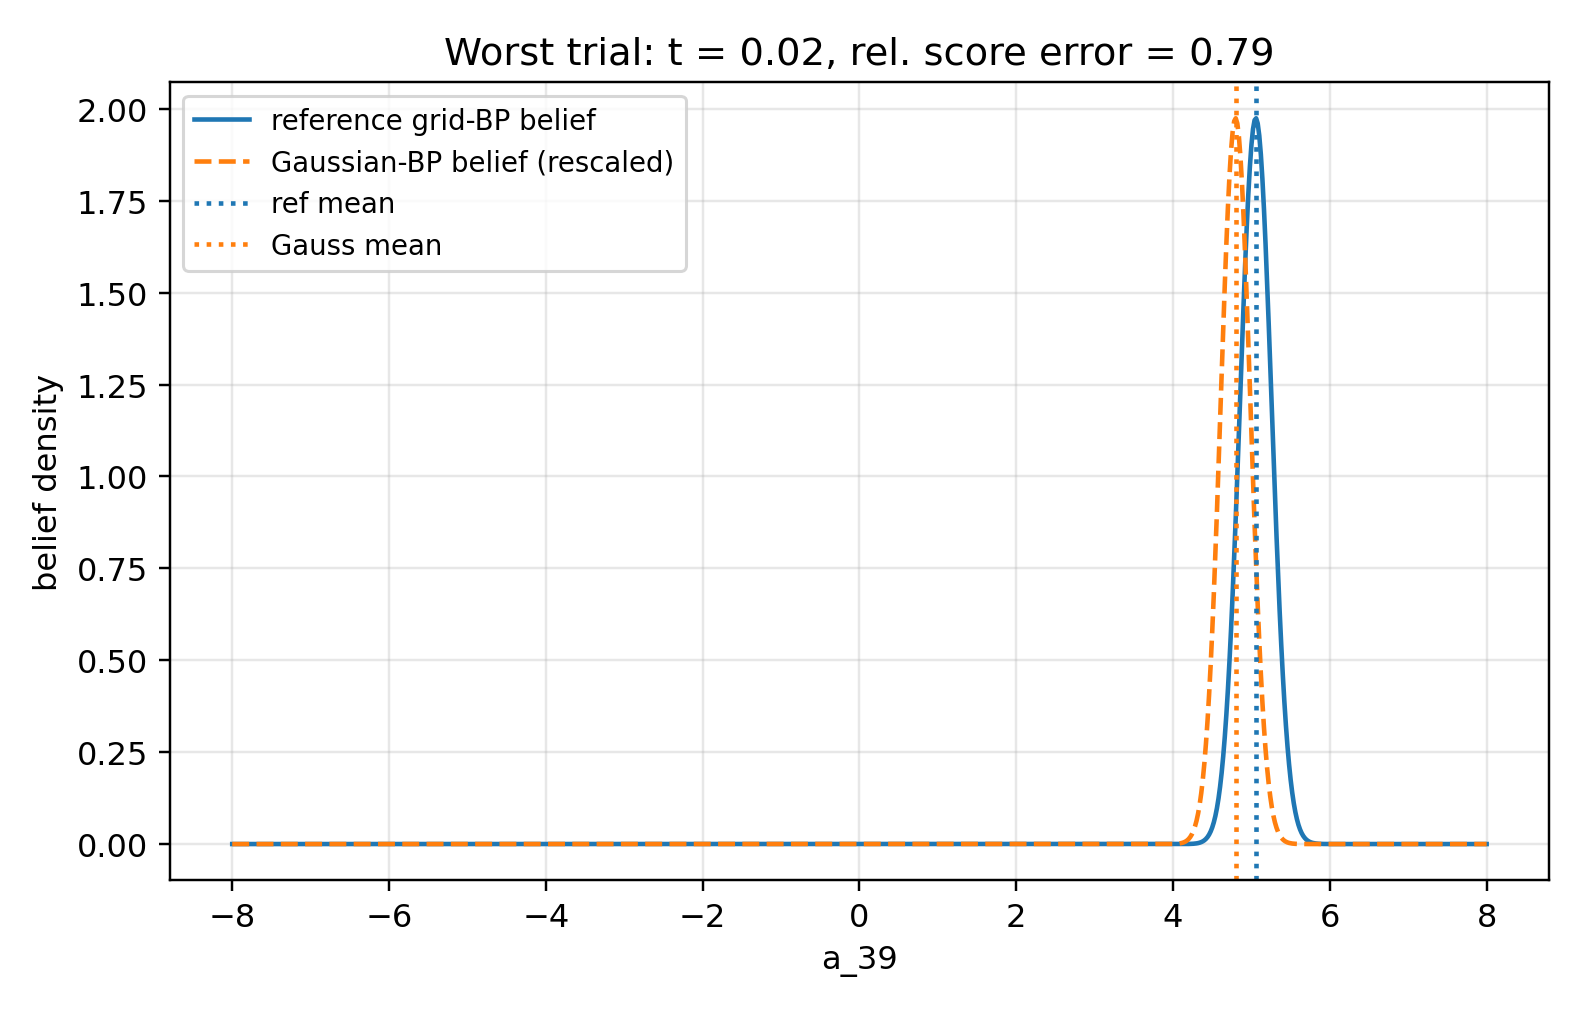

In [3]:
show("laplace_closure_vs_grid_budget.png", "legacy_artifact_size.png",
     "laplace_worst_case_belief.png", exp=exp2)

## Innovation sweep: heavy tails vs bimodality

In [4]:
exp3 = "exp_03_nongaussian_innovation_sweep"
print((OUT / exp3 / "SUMMARY_TABLE.md").read_text())

# When does the Gaussian score baseline work?

Median relative score error of the analytic Gaussian baseline (== covariance-matched Gaussian model) vs fine-grid BP.

| family | kurt. | rho | small t (min) | mid t (0.2) | large t (max) |
|---|---|---|---|---|---|
| gauss_mix_kappa0.3 | -0.18 | 0.5 | 0.068 | 0.026 | 0.000 |
| gauss_mix_kappa0.6 | -0.72 | 0.5 | 0.405 | 0.118 | 0.000 |
| gauss_mix_kappa0.9 | -1.62 | 0.5 | 0.939 | 0.346 | 0.000 |
| laplace | +3.00 | 0.5 | 0.520 | 0.233 | 0.000 |
| student_t_nu5 | +6.00 | 0.5 | 0.317 | 0.159 | 0.000 |
| student_t_nu8 | +1.50 | 0.5 | 0.196 | 0.082 | 0.000 |
| gauss_mix_kappa0.3 | -0.18 | 0.85 | 0.051 | 0.006 | 0.000 |
| gauss_mix_kappa0.6 | -0.72 | 0.85 | 0.255 | 0.036 | 0.000 |
| gauss_mix_kappa0.9 | -1.62 | 0.85 | 0.714 | 0.100 | 0.000 |
| laplace | +3.00 | 0.85 | 0.354 | 0.080 | 0.000 |
| student_t_nu5 | +6.00 | 0.85 | 0.241 | 0.059 | 0.000 |
| student_t_nu8 | +1.50 | 0.85 | 0.138 | 0.030 | 0.000 |
| gauss_mix_kappa0.3 | -0.18 | 0.95 | 0.0

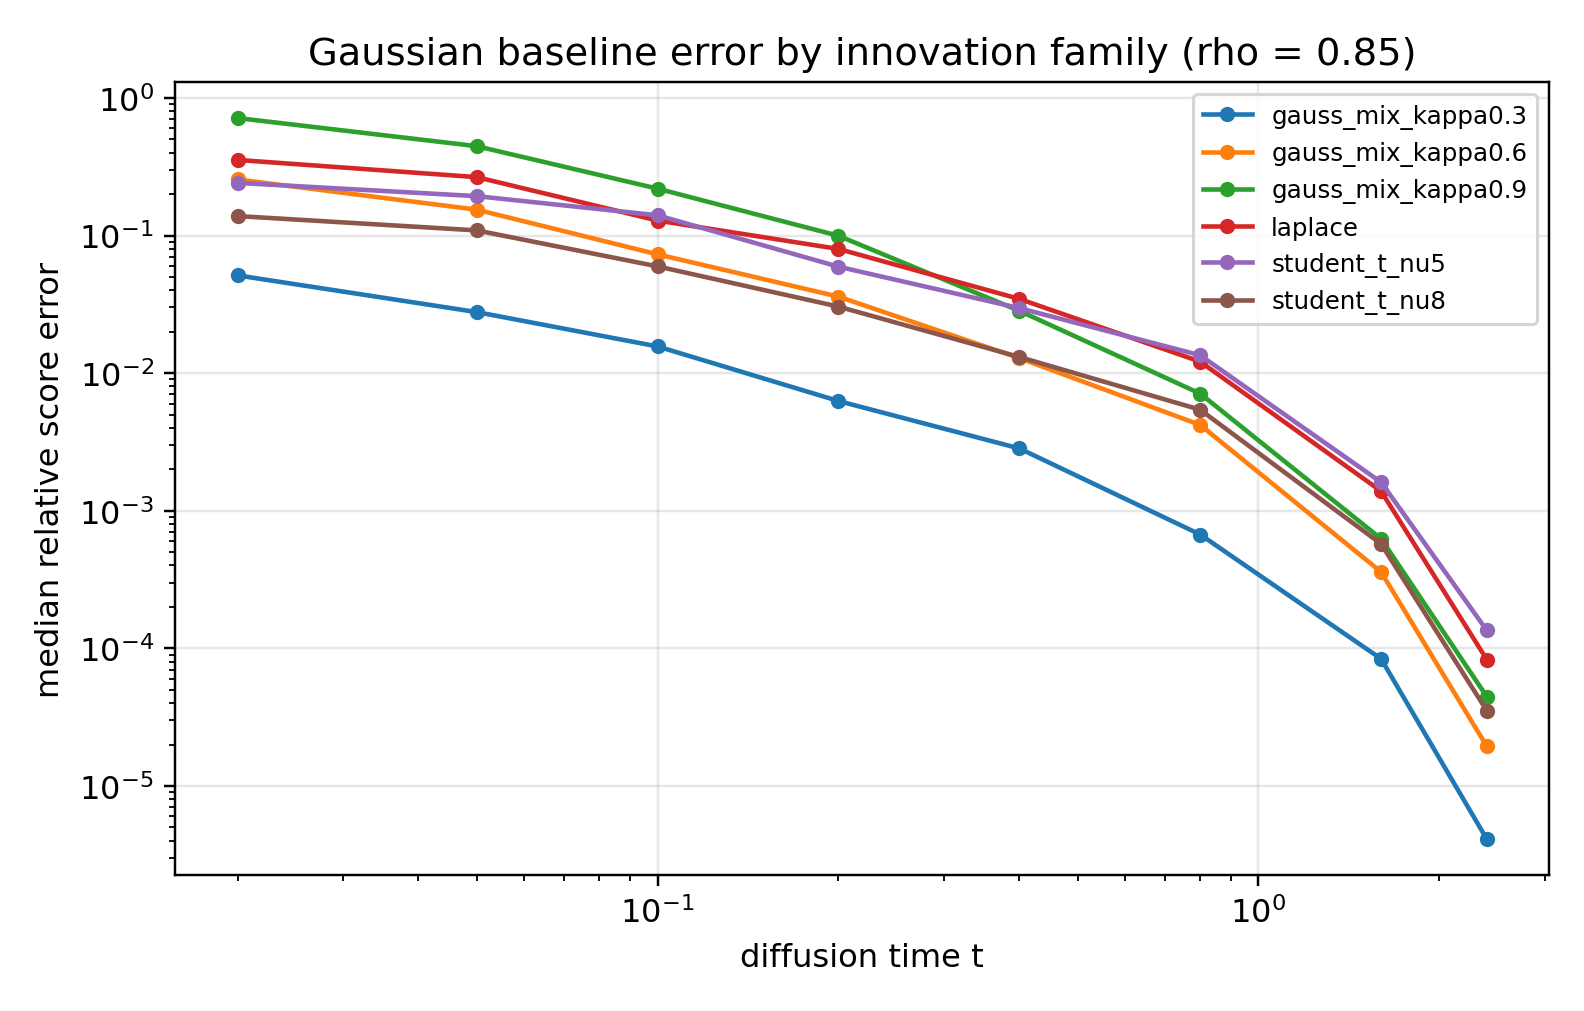

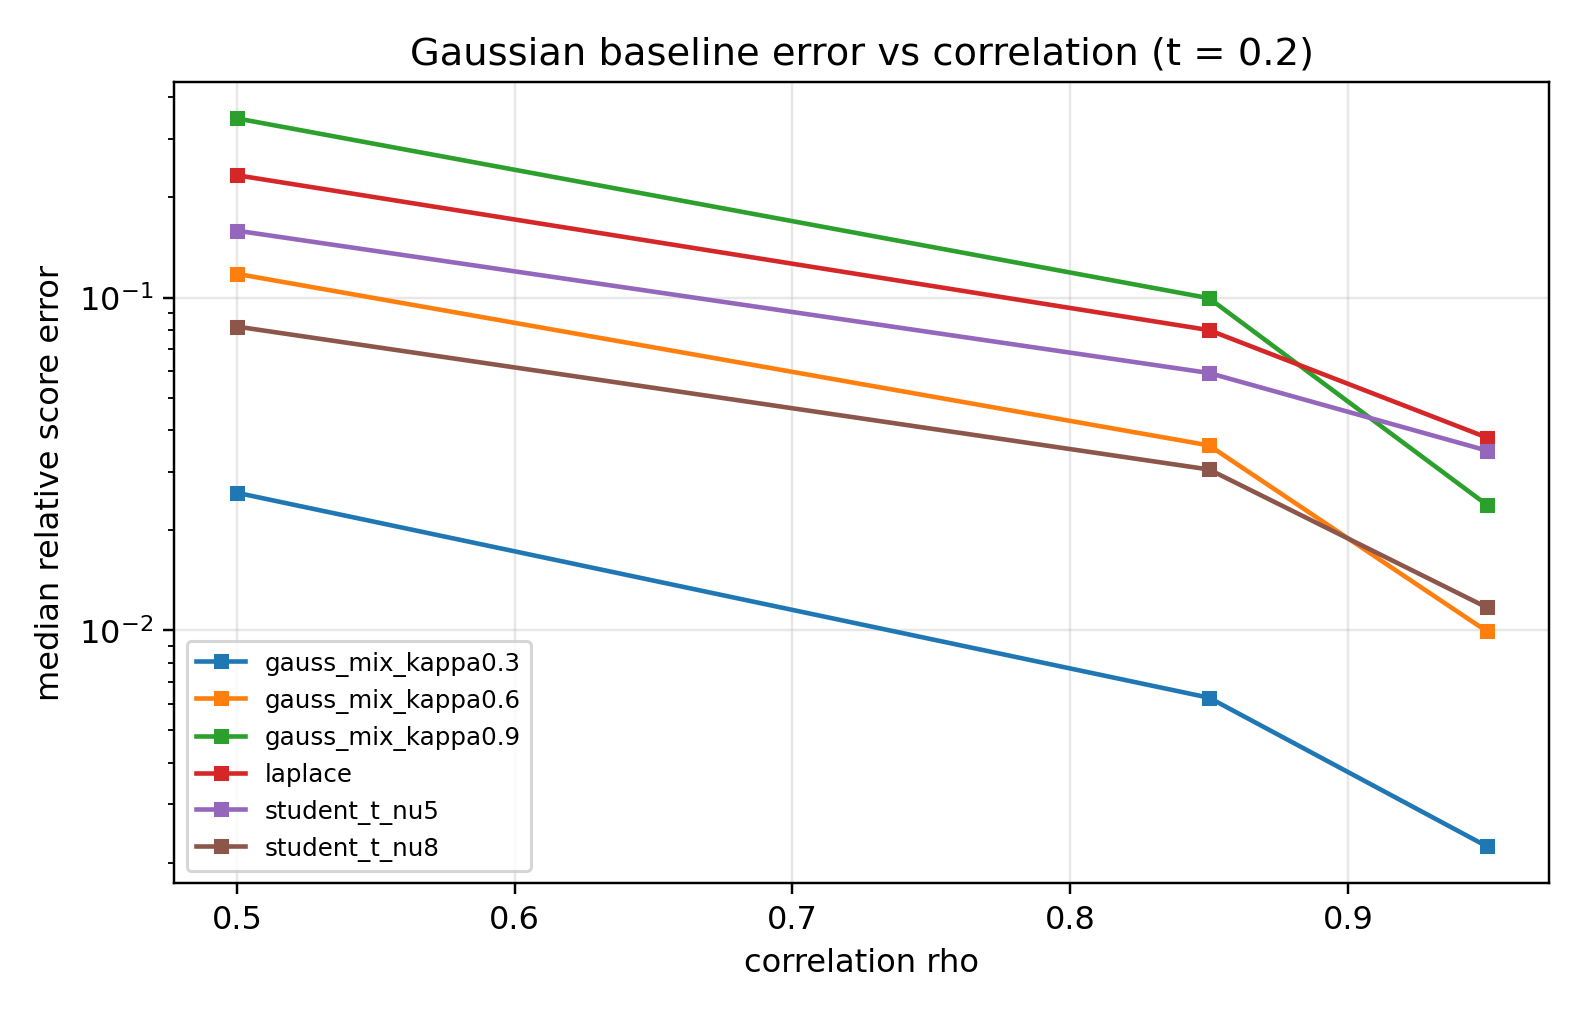

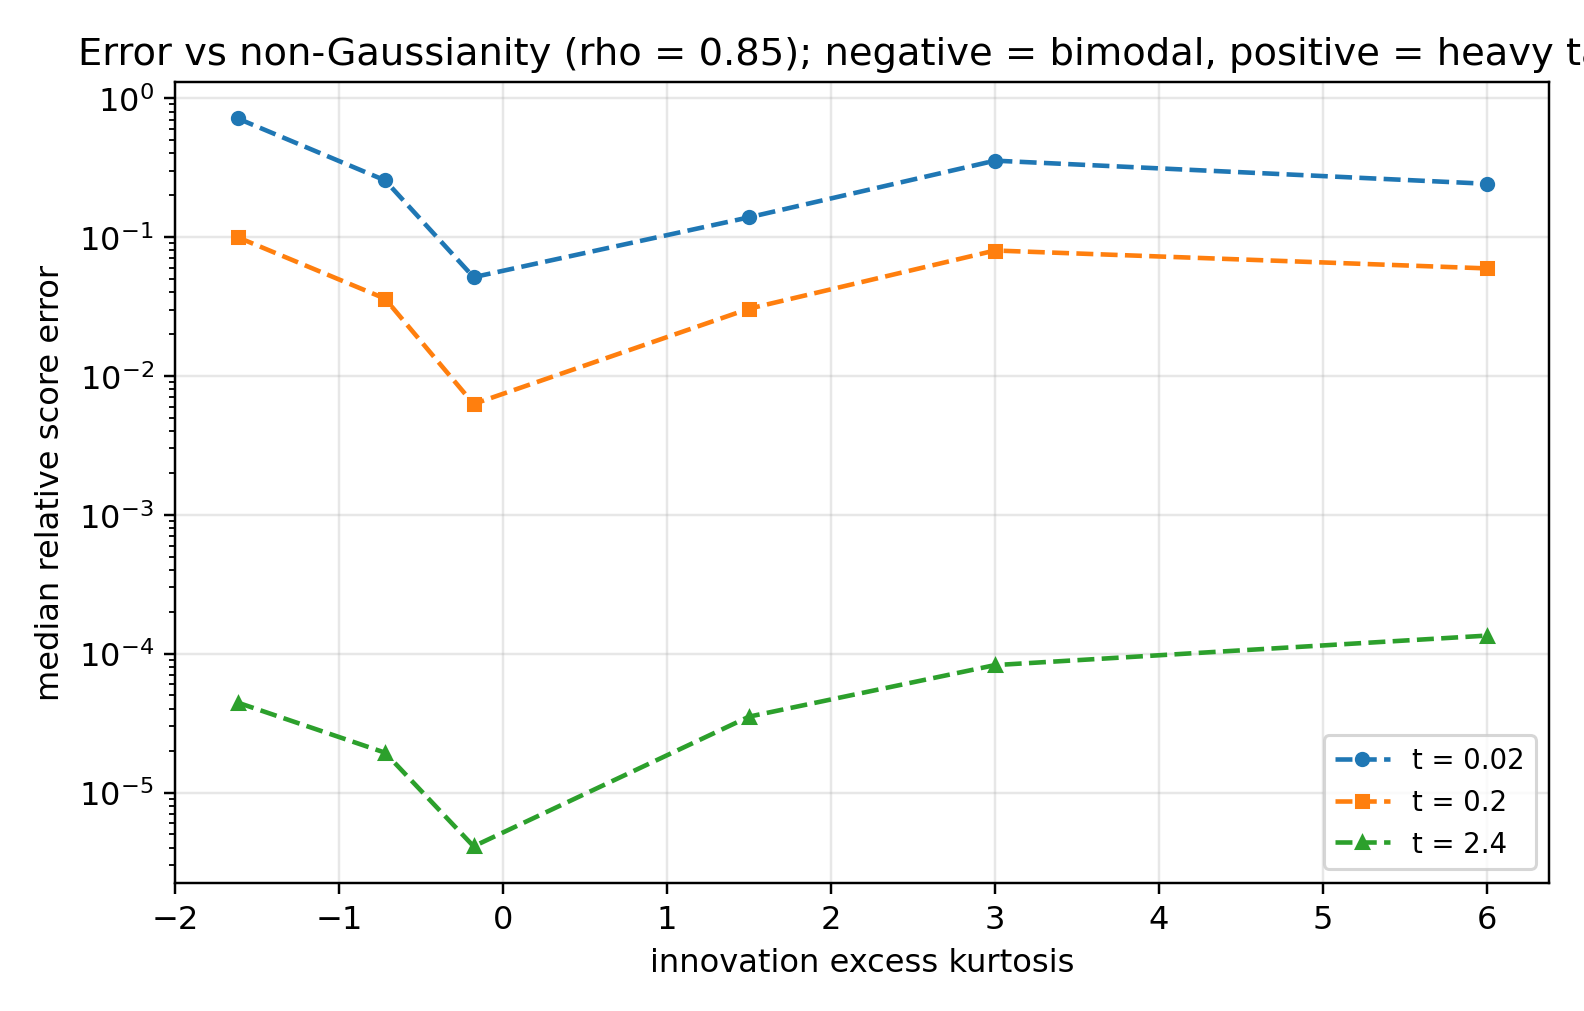

In [5]:
show("sweep_error_vs_t.png", "sweep_error_vs_rho.png", "sweep_error_vs_kurtosis.png", exp=exp3)

Findings: error grows with $|$excess kurtosis$|$ in both directions (bimodal mixtures
are the worst case at equal $|\kappa_4|$); **stronger correlation $\rho$ *helps* the
Gaussian baseline** at fixed $t$ (informative neighbours Gaussianize the local
posterior), contrary to the naive error-propagation intuition.